# GTSRB Stop Sign Classification

I used my homework 8 from my SP25 Neural Networks class to inspire much of this training code. I also used AI generation to aid in debugging and code generation for helping export to .mat files

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import csv
import os
from pathlib import Path
from fastprogress import master_bar, progress_bar
from collections import defaultdict
import random

# Use the GPUs if they are available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using '{device}' device.")

Using 'cpu' device.


In [18]:
# Data paths
GTSRB_ROOT = './GTSRB/Final_Training/Images'
IMAGE_SIZE = 32  # Resize all images to 32x32
STOP_CLASS_ID = 14  # Stop sign class ID

In [ ]:
# adapted from Python code for GTSRB repository at https://benchmark.ini.rub.de/gtsrb_dataset.html
def readTrafficSigns(rootpath):
    '''Reads traffic sign data for German Traffic Sign Recognition Benchmark.
    
    Arguments: path to the traffic sign data
    Returns:   list of images (as numpy arrays), list of corresponding labels (as ints)'''
    images = []
    labels = []
    
    # Loop over all 43 classes (00000 to 00042)
    for c in range(0, 43):
        prefix = os.path.join(rootpath, format(c, '05d'))
        csv_file = os.path.join(prefix, f'GT-{format(c, "05d")}.csv')
        
        if not os.path.exists(csv_file):
            continue
            
        with open(csv_file, 'r') as gtFile:
            gtReader = csv.reader(gtFile, delimiter=';')
            next(gtReader)  # Skip header
            
            # Loop over all images in current annotations file
            for row in gtReader:
                if len(row) < 8:
                    continue
                img_path = os.path.join(prefix, row[0])
                if os.path.exists(img_path):
                    # Load image and resize
                    img = plt.imread(img_path)
                    img_pil = Image.fromarray(img) if img.dtype == np.uint8 else Image.fromarray((img * 255).astype(np.uint8))
                    img_pil = img_pil.resize((IMAGE_SIZE, IMAGE_SIZE))
                    img_array = np.array(img_pil, dtype=np.float32) / 255.0
                    images.append(img_array)
                    labels.append(int(row[7]))  # ClassId is the 8th column (index 7)
    
    return images, labels

In [ ]:
class GTSRBDataset(Dataset):
    """GTSRB Dataset for binary classification. Pixel values in [0, 1] (training and export)."""
    
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels  # Binary: 0 = Not-Stop, 1 = Stop
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Convert to tensor and change from HWC to CHW format
        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image).permute(2, 0, 1)  # HWC -> CHW
        
        return image.float(), torch.tensor(label, dtype=torch.long)

In [21]:
class CNNA(nn.Module):
    """2 conv layers (16, 32 filters, 4x4, stride 2), FC 100 units."""
    def __init__(self, num_classes=2):
        super(CNNA, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 100),
            nn.ReLU(),
            nn.Linear(100, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class CNNB(nn.Module):
    """Large network: 4 conv layers (32, 32, 64, 64 filters), 2 FC layers of 512 units."""
    
    def __init__(self, num_classes=2):
        super(CNNB, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=4, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=4, padding=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [22]:
# Load all GTSRB data
print("Loading GTSRB dataset...")
all_images, all_labels = readTrafficSigns(GTSRB_ROOT)
print(f"Loaded {len(all_images)} images")

# Separate Stop signs (positive) and non-Stop signs (negative)
stop_images = []
stop_labels = []
nonstop_images = []
nonstop_labels = []

for img, label in zip(all_images, all_labels):
    if label == STOP_CLASS_ID:
        stop_images.append(img)
        stop_labels.append(1)  # Stop = 1
    else:
        nonstop_images.append(img)
        nonstop_labels.append(0)  # Not-Stop = 0

print(f"Stop signs: {len(stop_images)}")
print(f"Non-Stop signs: {len(nonstop_images)}")

# Split into train/test sets BEFORE any training (proper train/test split)
# Hold out 20% of Stop signs and 20% of non-Stop signs for testing
test_split_ratio = 0.2
random.seed(42)
np.random.seed(42)

# Split Stop signs: 80% train, 20% test
num_test_stops = int(len(stop_images) * test_split_ratio)
test_stop_indices = random.sample(range(len(stop_images)), num_test_stops)
train_stop_indices = [i for i in range(len(stop_images)) if i not in test_stop_indices]

train_stop_images = [stop_images[i] for i in train_stop_indices]
train_stop_labels = [stop_labels[i] for i in train_stop_indices]
test_stop_images = [stop_images[i] for i in test_stop_indices]
test_stop_labels = [stop_labels[i] for i in test_stop_indices]

# Split non-Stop signs: 80% train, 20% test
num_test_nonstops = int(len(nonstop_images) * test_split_ratio)
test_nonstop_indices = random.sample(range(len(nonstop_images)), num_test_nonstops)
train_nonstop_indices = [i for i in range(len(nonstop_images)) if i not in test_nonstop_indices]

train_nonstop_images = [nonstop_images[i] for i in train_nonstop_indices]
train_nonstop_labels = [nonstop_labels[i] for i in train_nonstop_indices]
test_nonstop_images = [nonstop_images[i] for i in test_nonstop_indices]
test_nonstop_labels = [nonstop_labels[i] for i in test_nonstop_indices]

print(f"\nTrain/Test Split:")
print(f"  Training Stop signs: {len(train_stop_images)}")
print(f"  Training Non-Stop signs: {len(train_nonstop_images)}")
print(f"  Test Stop signs: {len(test_stop_images)}")
print(f"  Test Non-Stop signs: {len(test_nonstop_images)}")
print(f"  Total training: {len(train_stop_images) + len(train_nonstop_images)}")
print(f"  Total test: {len(test_stop_images) + len(test_nonstop_images)}")

Loading GTSRB dataset...
Loaded 39209 images
Stop signs: 780
Non-Stop signs: 38429

Train/Test Split:
  Training Stop signs: 624
  Training Non-Stop signs: 30744
  Test Stop signs: 156
  Test Non-Stop signs: 7685
  Total training: 31368
  Total test: 7841


In [ ]:
# Initial balanced training dataset: all training Stop signs + random training non-Stop signs
target_ratio = 1.5  # Start with 1.5:1 ratio
num_negatives = min(int(len(train_stop_images) * target_ratio), len(train_nonstop_images))

# Randomly sample training non-Stop signs for initial training
selected_train_nonstop_indices = random.sample(range(len(train_nonstop_images)), num_negatives)

train_images = train_stop_images + [train_nonstop_images[i] for i in selected_train_nonstop_indices]
train_labels = train_stop_labels + [train_nonstop_labels[i] for i in selected_train_nonstop_indices]

# Shuffle
combined = list(zip(train_images, train_labels))
random.shuffle(combined)
train_images, train_labels = zip(*combined)
train_images = list(train_images)
train_labels = list(train_labels)

print(f"\nInitial training set: {len(train_images)} images")
print(f"Stop signs: {sum(train_labels)}")
print(f"Non-Stop signs: {len(train_labels) - sum(train_labels)}")


Initial training set: 1560 images
  - Stop signs: 624
  - Non-Stop signs: 936


In [ ]:
# Create dataset and dataloader
train_dataset = GTSRBDataset(train_images, train_labels)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

num_epochs = 10
learning_rate = 0.001

model = CNNA(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

Model created with 214110 parameters


In [ ]:
# Training function (similar style to hw8 of my Neural Networks class)
def train_epoch(model, train_loader, criterion, optimizer, device, mb=None):
    model.train()
    train_loss_mean = 0
    train_correct = 0
    train_N = len(train_loader.dataset)
    num_train_batches = len(train_loader)
    train_dataiterator = iter(train_loader)
    
    # Use progress_bar if mb is provided (like hw8)
    batch_range = progress_bar(range(num_train_batches), parent=mb) if mb is not None else range(num_train_batches)
    
    for batch in batch_range:
        
        X, Y = next(train_dataiterator)
        X, Y = X.to(device), Y.to(device)
        
        output = model(X)
        loss = criterion(output, Y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        num_in_batch = len(X)
        train_loss_mean += loss.item() * num_in_batch / train_N
        predictions = output.argmax(1)
        train_correct += (predictions == Y).type(torch.float).sum().item()
    
    train_accuracy = 100 * (train_correct / train_N)
    return train_loss_mean, train_accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss_mean = 0
    val_correct = 0
    val_N = len(val_loader.dataset)
    
    with torch.no_grad():
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            output = model(X)
            loss = criterion(output, Y)
            
            num_in_batch = len(X)
            val_loss_mean += loss.item() * num_in_batch / val_N
            predictions = output.argmax(1)
            val_correct += (predictions == Y).type(torch.float).sum().item()
    
    val_accuracy = 100 * (val_correct / val_N)
    return val_loss_mean, val_accuracy

Starting initial training...


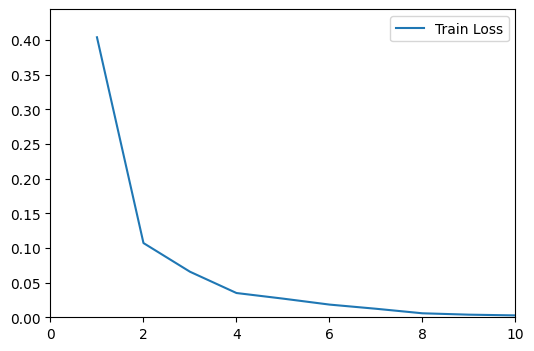


Initial training complete!
Final Train Accuracy: 100.00%


In [ ]:
# Initial training
print("Starting initial training...")
mb = master_bar(range(num_epochs))
mb.names = ["Train Loss", "Train Acc"]

train_losses = []
train_accs = []

for epoch in mb:
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, mb)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    mb.write(f"[{epoch+1:>2}/{num_epochs}] Train Loss = {train_loss:.4f}; Train Acc = {train_acc:.2f}%")
    

    if len(train_losses) > 1:
        x_bounds = [0, num_epochs]
        y_bounds = [0, max(train_losses) * 1.1]
        x_axis = torch.linspace(1, epoch + 1, len(train_losses))
        graph_data = [[x_axis, train_losses]]
        mb.update_graph(graph_data, x_bounds, y_bounds)

print(f"\nInitial training complete!")
print(f"Final Train Accuracy: {train_accs[-1]:.2f}%")

### HARD NEGATIVE MINING (Training round 2)

In [ ]:
print("\nPerforming hard-negative mining...")
model.eval()

# Get training non-Stop images that weren't in initial training
remaining_train_nonstop_indices = [i for i in range(len(train_nonstop_images)) if i not in selected_train_nonstop_indices]
remaining_train_nonstop_images = [train_nonstop_images[i] for i in remaining_train_nonstop_indices]

# Create temporary dataset for mining (only from training set!)
temp_dataset = GTSRBDataset(remaining_train_nonstop_images, [0] * len(remaining_train_nonstop_images))
temp_loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)

hard_negatives = []
hard_negative_probs = []

with torch.no_grad():
    batch_start_idx = 0
    for X, _ in temp_loader:
        X = X.to(device)
        output = model(X)
        probs = torch.softmax(output, dim=1)  # Get probabilities for mining
        stop_probs = probs[:, 1].cpu().numpy()  # Probability of being Stop
        
        # Find high Stop-probability examples (potential false positives)
        for i, prob in enumerate(stop_probs):
            if prob > 0.3:  # Threshold for hard negatives
                actual_idx = batch_start_idx + i
                if actual_idx < len(remaining_train_nonstop_indices):
                    hard_negatives.append(remaining_train_nonstop_indices[actual_idx])
                    hard_negative_probs.append(prob)
        
        batch_start_idx += len(X)

print(f"Found {len(hard_negatives)} hard negatives")

# Add hard negatives to training set (maintain ratio)
if len(hard_negatives) > 0:
    
    max_hard_negatives = min(len(hard_negatives), int(len(train_stop_images) * 1.0))
    selected_hard_negatives = sorted(range(len(hard_negatives)), 
                                     key=lambda i: hard_negative_probs[i], 
                                     reverse=True)[:max_hard_negatives]
    
    train_images.extend([train_nonstop_images[hard_negatives[i]] for i in selected_hard_negatives])
    train_labels.extend([0] * len(selected_hard_negatives))
    
    # Shuffle
    combined = list(zip(train_images, train_labels))
    random.shuffle(combined)
    train_images, train_labels = zip(*combined)
    train_images = list(train_images)
    train_labels = list(train_labels)
    
    print(f"Updated training set: {len(train_images)} images")
    print(f"Stop signs: {sum(train_labels)}")
    print(f"Non-Stop signs: {len(train_labels) - sum(train_labels)}")
    
    # Recreate dataset and loader
    train_dataset = GTSRBDataset(train_images, train_labels)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Performing hard-negative mining...
Found 292 hard negatives
Updated training set: 1852 images
  - Stop signs: 624
  - Non-Stop signs: 1228



Retraining with hard negatives...


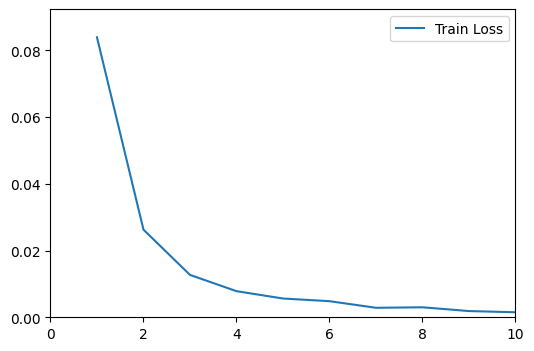


Retraining complete!
Final Train Accuracy: 100.00%


In [28]:
# Retrain with hard negatives
print("\nRetraining with hard negatives...")
mb = master_bar(range(num_epochs))
mb.names = ["Train Loss", "Train Acc"]

train_losses_retrain = []
train_accs_retrain = []

for epoch in mb:
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, mb)
    train_losses_retrain.append(train_loss)
    train_accs_retrain.append(train_acc)
    
    mb.write(f"[{epoch+1:>2}/{num_epochs}] Train Loss = {train_loss:.4f}; Train Acc = {train_acc:.2f}%")
    
    # Update plot
    if len(train_losses_retrain) > 1:
        x_bounds = [0, num_epochs]
        y_bounds = [0, max(train_losses_retrain) * 1.1]
        x_axis = torch.linspace(1, epoch + 1, len(train_losses_retrain))
        graph_data = [[x_axis, train_losses_retrain]]
        mb.update_graph(graph_data, x_bounds, y_bounds)

print(f"\nRetraining complete!")
print(f"Final Train Accuracy: {train_accs_retrain[-1]:.2f}%")

In [ ]:
print("\nPreparing test set...")

# Combine test Stop and non-Stop images (already split at the beginning)
# Sample test negatives to match test positives ratio of 1.5:1
num_test_negatives = min(int(len(test_stop_images) * 1.5), len(test_nonstop_images))
test_nonstop_selected_indices = random.sample(range(len(test_nonstop_images)), num_test_negatives)

test_images = test_stop_images + [test_nonstop_images[i] for i in test_nonstop_selected_indices]
test_labels = test_stop_labels + [test_nonstop_labels[i] for i in test_nonstop_selected_indices]

combined_test = list(zip(test_images, test_labels))
random.shuffle(combined_test)
test_images, test_labels = zip(*combined_test)
test_images = list(test_images)
test_labels = list(test_labels)

print(f"Test set: {len(test_images)} images")
print(f"Stop signs: {sum(test_labels)}")
print(f"Non-Stop signs: {len(test_labels) - sum(test_labels)}")

test_dataset = GTSRBDataset(test_images, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Preparing test set...
Test set: 390 images
  - Stop signs: 156
  - Non-Stop signs: 234


### Prepare for export to Julia

In [ ]:
# export the exact eval tensors for Julia/MIPVerify (same order & scaling as test_loader / test_accuracy)
import sys
from pathlib import Path

for root in [Path.cwd(), *Path.cwd().parents]:
    if (root / "export_test_data.py").exists():
        sys.path.insert(0, str(root))
        break
else:
    raise ImportError("Could not find export_test_data.py — run the notebook with working directory set to the math190 folder.")

from export_test_data import export_gtsrb_eval_tensors

out_path = root / "gtsrb_test_eval.mat"
export_gtsrb_eval_tensors(test_images, test_labels, output_file=str(out_path))
print(f"Julia: load with load_gtsrb_test_data({out_path.name!r}) or GTSRB_MAT={out_path.name} julia cnna.jl")


Eval export shape=(390, 32, 32, 3), labels=(390,)
  pixel range [0.0000, 1.0000] (expect ~[0, 1] for current training)
  Stop=156, Non-stop=234
Saved /Users/juliannelouie/Desktop/math190/gtsrb_test_eval.mat
Julia: load with load_gtsrb_test_data('gtsrb_test_eval.mat') or GTSRB_MAT=gtsrb_test_eval.mat julia cnna.jl



Analyzing misclassifications...
Found 2 misclassified images out of 390
Misclassified images saved to ./misclassified_test_images.png


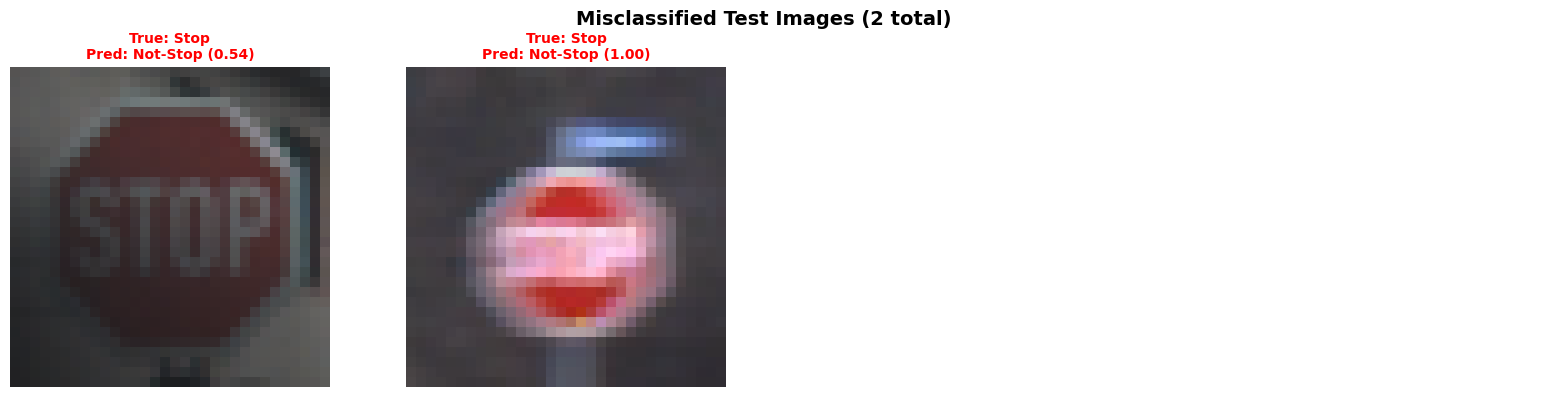


Misclassification Summary:
  False Positives (Not-Stop → Stop): 0
  False Negatives (Stop → Not-Stop): 2


In [31]:
# Visualize misclassified test images
print("\nAnalyzing misclassifications...")
model.eval()

# Collect all test predictions and identify misclassifications
all_test_predictions = []
all_test_labels = []
all_test_probs = []
misclassified_indices = []

with torch.no_grad():
    batch_start_idx = 0
    for test_X, test_Y in test_loader:
        test_X = test_X.to(device)
        test_output = model(test_X)
        probs = torch.softmax(test_output, dim=1)
        predictions = test_output.argmax(1).cpu().numpy()
        
        for i in range(len(test_Y)):
            actual_idx = batch_start_idx + i
            all_test_predictions.append(predictions[i])
            all_test_labels.append(test_Y[i].item())
            all_test_probs.append(probs[i].cpu().numpy())
            
            if predictions[i] != test_Y[i].item():
                misclassified_indices.append(actual_idx)
        
        batch_start_idx += len(test_Y)

print(f"Found {len(misclassified_indices)} misclassified images out of {len(all_test_labels)}")

# Visualize misclassified images
if len(misclassified_indices) > 0:
    # Show up to 16 misclassified images
    num_to_show = min(len(misclassified_indices), 16)
    selected_misclassified = misclassified_indices[:num_to_show]
    
    cols = 4
    rows = (num_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, mis_idx in enumerate(selected_misclassified):
        img = test_images[mis_idx]
        true_label = all_test_labels[mis_idx]
        pred_label = all_test_predictions[mis_idx]
        prob = all_test_probs[mis_idx]
        
        if isinstance(img, np.ndarray):
            img = (img * 255).astype(np.uint8)
        
        axes[idx].imshow(img)
        true_label_str = "Stop" if true_label == 1 else "Not-Stop"
        pred_label_str = "Stop" if pred_label == 1 else "Not-Stop"
        pred_prob = prob[pred_label]
        
        # Color: red for misclassification
        axes[idx].set_title(f'True: {true_label_str}\nPred: {pred_label_str} ({pred_prob:.2f})', 
                          color='red', fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(num_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified Test Images ({len(misclassified_indices)} total)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./misclassified_test_images.png', dpi=150, bbox_inches='tight')
    print(f"Misclassified images saved to ./misclassified_test_images.png")
    plt.show()
    
    # Print summary statistics
    print(f"\nMisclassification Summary:")
    false_positives = sum(1 for i in misclassified_indices 
                         if all_test_labels[i] == 0 and all_test_predictions[i] == 1)
    false_negatives = sum(1 for i in misclassified_indices 
                         if all_test_labels[i] == 1 and all_test_predictions[i] == 0)
    print(f"  False Positives (Not-Stop → Stop): {false_positives}")
    print(f"  False Negatives (Stop → Not-Stop): {false_negatives}")
else:
    print("Perfect classification! No misclassified images to visualize.")

In [ ]:
print("\nEvaluating on test set...")
model.eval()

test_N = len(test_loader.dataset)
num_test_batches = len(test_loader)

test_loss_mean = 0
test_correct = 0

with torch.no_grad():
    
    for test_X, test_Y in test_loader:
        test_X, test_Y = test_X.to(device), test_Y.to(device)
        
        test_output = model(test_X)
        test_loss = criterion(test_output, test_Y)
        
        num_in_batch = len(test_X)
        test_loss_mean += test_loss.item() * num_in_batch / test_N
        
        # Convert network output into predictions
        predictions = test_output.argmax(1)
        
        # Sum up total number that were correct
        test_correct += (predictions == test_Y).type(torch.float).sum().item()

test_accuracy = 100 * (test_correct / test_N)

print(f"\nTest Results:")
print(f"  Test Loss = {test_loss_mean:.4f}")
print(f"  Test Accuracy = {test_accuracy:.2f}%")
print(f"  Correct: {test_correct:.0f}/{test_N}")


Evaluating on test set...

Test Results:
  Test Loss = 0.0234
  Test Accuracy = 99.49%
  Correct: 388/390


In [33]:
# Save model weights
model_path = './gtsrb_stop_sign_CNNA.pth'
torch.save(model.state_dict(), model_path)
print(f"\nModel weights saved to {model_path}")

# Also save model architecture info for MIPVerify
model_info = {
    'architecture': 'CNNA',
    'input_size': IMAGE_SIZE,
    'num_classes': 2,
    'conv1': {'in_channels': 3, 'out_channels': 16, 'kernel_size': 4, 'stride': 2, 'padding': 1},
    'conv2': {'in_channels': 16, 'out_channels': 32, 'kernel_size': 4, 'stride': 2, 'padding': 1},
    'fc1': {'in_features': 32 * 8 * 8, 'out_features': 100},
    'fc2': {'in_features': 100, 'out_features': 2},
    'test_accuracy': test_accuracy,
    'test_loss': test_loss_mean
}

import json
with open('./gtsrb_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("Model info saved to ./gtsrb_model_info.json")


Model weights saved to ./gtsrb_stop_sign_CNNA.pth
Model info saved to ./gtsrb_model_info.json


Sample predictions saved to ./predictions_sample.png


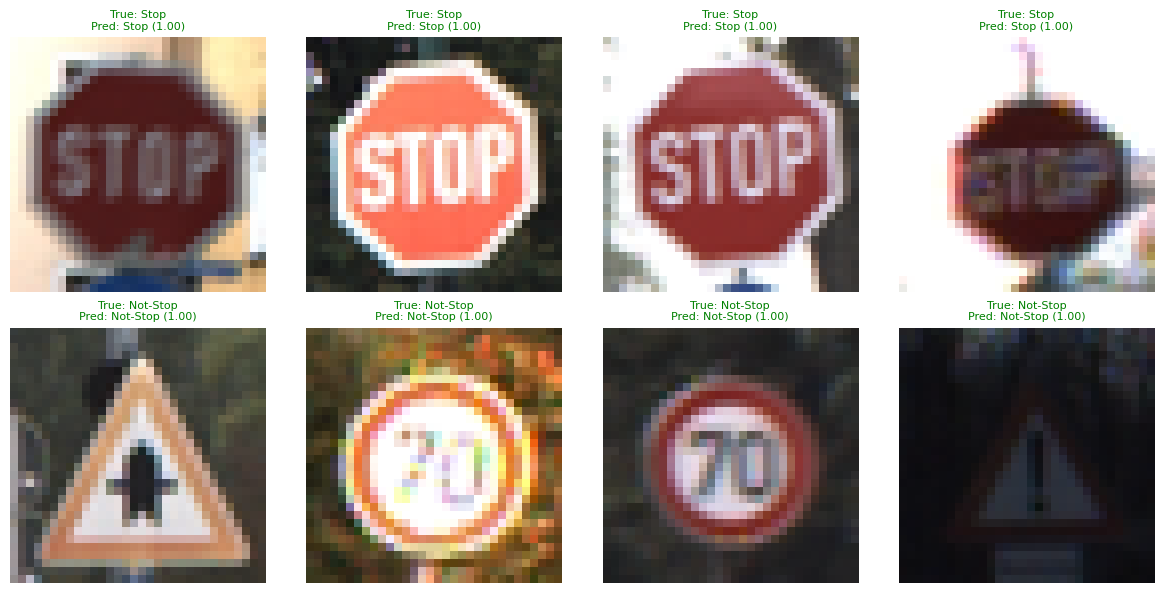

In [34]:
# Visualize some predictions
model.eval()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Get a batch of test images
test_images_sample = test_stop_images[:4] + [test_nonstop_images[i] for i in random.sample(range(len(test_nonstop_images)), 4)]
test_labels_sample = [1, 1, 1, 1, 0, 0, 0, 0]

test_dataset_sample = GTSRBDataset(test_images_sample, test_labels_sample)
test_loader_sample = DataLoader(test_dataset_sample, batch_size=8, shuffle=False)

with torch.no_grad():
    for X, Y in test_loader_sample:
        X = X.to(device)
        output = model(X)
        probs = torch.softmax(output, dim=1)
        predictions = output.argmax(1).cpu().numpy()
        
        for i in range(8):
            img = test_images_sample[i]
            if isinstance(img, np.ndarray):
                img = (img * 255).astype(np.uint8)
            
            axes[i].imshow(img)
            true_label = "Stop" if test_labels_sample[i] == 1 else "Not-Stop"
            pred_label = "Stop" if predictions[i] == 1 else "Not-Stop"
            prob = probs[i, 1].item() if predictions[i] == 1 else probs[i, 0].item()
            color = 'green' if predictions[i] == test_labels_sample[i] else 'red'
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({prob:.2f})', 
                            color=color, fontsize=8)
            axes[i].axis('off')

plt.tight_layout()
plt.savefig('./predictions_sample.png', dpi=150, bbox_inches='tight')
print("Sample predictions saved to ./predictions_sample.png")
plt.show()

Sample predictions saved to ./predictions_sample.png


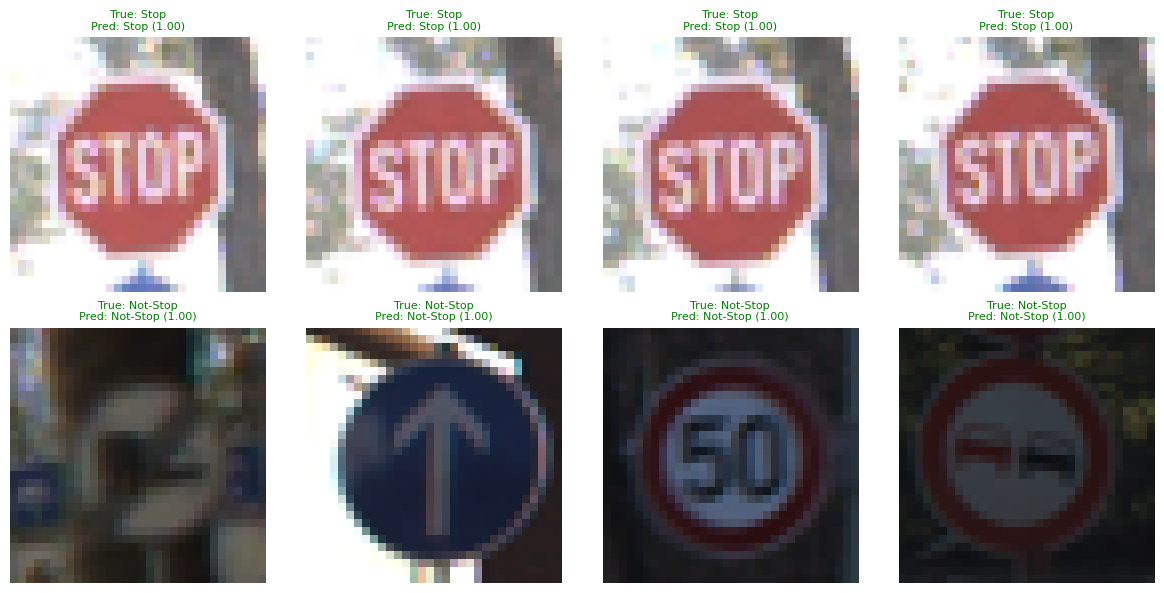

In [35]:
# Visualize some predictions
model.eval()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Get a batch of test images
test_images = stop_images[:4] + [nonstop_images[i] for i in random.sample(range(len(nonstop_images)), 4)]
test_labels = [1, 1, 1, 1, 0, 0, 0, 0]

test_dataset = GTSRBDataset(test_images, test_labels)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

with torch.no_grad():
    for X, Y in test_loader:
        X = X.to(device)
        output = model(X)
        probs = torch.softmax(output, dim=1)
        predictions = output.argmax(1).cpu().numpy()
        
        for i in range(8):
            img = test_images[i]
            if isinstance(img, np.ndarray):
                img = (img * 255).astype(np.uint8)
            
            axes[i].imshow(img)
            true_label = "Stop" if test_labels[i] == 1 else "Not-Stop"
            pred_label = "Stop" if predictions[i] == 1 else "Not-Stop"
            prob = probs[i, 1].item() if predictions[i] == 1 else probs[i, 0].item()
            color = 'green' if predictions[i] == test_labels[i] else 'red'
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({prob:.2f})', 
                            color=color, fontsize=8)
            axes[i].axis('off')

plt.tight_layout()
plt.savefig('./predictions_sample.png', dpi=150, bbox_inches='tight')
print("Sample predictions saved to ./predictions_sample.png")
plt.show()

In [36]:
import torch
import scipy.io as sio
import numpy as np

# Load your trained model
model = CNNA(num_classes=2)
model.load_state_dict(torch.load('/Users/juliannelouie/Desktop/math190/gtsrb_stop_sign_CNNA.pth'))
model.eval()

# Extract parameters and convert to numpy
param_dict = {}

for name, param in model.named_parameters():
    # Convert PyTorch tensor to numpy
    # Note: PyTorch uses [out_channels, in_channels, H, W] for conv layers
    # You may need to transpose/reshape depending on what MIPVerify expects
    param_dict[name] = param.detach().cpu().numpy()

# Save as .mat file
sio.savemat('gtsrb_cnna_weights01.mat', param_dict)
print("Model exported to gtsrb_cnna_weights.mat")

Model exported to gtsrb_cnna_weights.mat


In [ ]:
# Export test data for Julia/MIPVerify
import scipy.io as sio

# Combine test images and labels
all_test_images = test_stop_images + test_nonstop_images
all_test_labels = test_stop_labels + test_nonstop_labels

# Convert to numpy arrays
all_test_images = np.stack(all_test_images, axis=0)
all_test_labels = np.array(all_test_labels)

# Apply normalization (same as training)
# all_test_images_normalized = (all_test_images - 0.5) / 0.5  # [-1, 1]
# Keep [0, 1] for MIPVerify-style pipeline (images already [0, 1] from load)
all_test_images_normalized = all_test_images.astype(np.float32)

print(f"Test images shape: {all_test_images_normalized.shape}")
print(f"Test labels shape: {all_test_labels.shape}")
print(f"Label distribution: Stop={np.sum(all_test_labels==1)}, Non-Stop={np.sum(all_test_labels==0)}")

# Save to .mat file
sio.savemat('gtsrb_test_data01.mat', {
    'test_images': all_test_images_normalized.astype(np.float32),
    'test_labels': all_test_labels.astype(np.int32),
    'stop_indices': np.where(all_test_labels == 1)[0].astype(np.int32),
    'nonstop_indices': np.where(all_test_labels == 0)[0].astype(np.int32)
})

print("Test data exported to gtsrb_test_data.mat")

Test images shape: (7841, 32, 32, 3)
Test labels shape: (7841,)
Label distribution: Stop=156, Non-Stop=7685
Test data exported to gtsrb_test_data.mat
